In [1]:
# Wspolne definicje (kopiowane bez zmian z 20260820a.ipynb / 20260819a.ipynb -
# ten sam, juz zwalidowany pipeline, patrz 20260819.txt pkt 14/18).
#
# Cel dzisiejszego notebooka (22.08.2026): test odpornosci klastra ekstremow
# 2006-2009 znalezionego 20.08 (pelny skan po t0, 22 stacje - patrz
# 20260820.txt pkt 8-9) na WYKLUCZENIE tego okresu z przestrzeni kandydatow
# t0. Ustalone z Maćkiem: nie interesuje nas juz "czy wynik przetrwa
# zaburzenie danych" (na to juz jest odpowiedz - KROK 4 z 20260820.txt pkt
# 15, efekt jest jednoznacznie po stronie CR, nie EQ). Pytanie na dzis:
# jesli w ogole NIE POZWOLIMY skanowi patrzec w okno 2006-2009, czy w
# pozostalej czesci zakresu (2010-2015) pojawi sie PODOBNIE silny ekstremum
# (co sugerowaloby "zawsze cos sie znajdzie" - artefakt nieskorygowanego
# przeszukania silnie skorelowanych kandydatow), czy skan wyraznie "ucichnie"
# (co byloby argumentem, ze 2006-2009 jest realnie wyjatkowe, nie przypadkowe).
#
# UWAGA metodologiczna: zalecenie z 20260820.txt pkt 10.3 mowilo o
# "przesunieciu zakresu kandydatow o pol roku" - ale klaster znalezionych
# ekstremow rozciaga sie na ~3.5 roku (2006-01-26 .. 2009-05-25, patrz tabele
# w 20260820.txt pkt 8), wiec przesuniecie startu o samo 6 miesiecy (np. z
# 2005-01 na 2005-07) w ogole NIE usunelo by tego okresu z kandydatow - test
# nie bylby wtedy niczego wart. Zamiast tego kandydaci t0 zaczynaja sie
# dopiero PO calym zaobserwowanym klastrze (patrz komorka z parametrami
# nizej) - to jedyny wybor, ktory faktycznie testuje postawione pytanie.
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

sys.path.insert(0, "..")
from mc_parallel import run_t0_scan_parallel

USGS_PATH = "../data/usgs_data/usgs_m4_2005_2025.csv"

def load_earthquakes(min_mag=4.0):
    df = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
    df = df[df["mag"] >= min_mag]
    return df.set_index("time")["mag"].sort_index()


def cosmoseismic_stat(cr, eq, t0, P_days, d_days, m, dt_days):
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)

    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_binned = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories)
    cr_vals = cr_binned.to_numpy()

    eq_in_range = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(eq_in_range.index, eq_edges, right=False)
    eq_binned = eq_in_range.groupby(eq_cats, observed=False).sum().reindex(eq_cats.categories, fill_value=0.0)
    sm_vals = eq_binned.to_numpy()

    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR = nCR_i - nCR_im1
    Sm = sm_vals[1:]

    med_Sm = np.nanmedian(Sm)
    med_dCR = np.nanmedian(np.abs(dCR))

    A = Sm / med_Sm - 1
    B = np.abs(dCR) / med_dCR - 1

    valid = (
        (A != 0) & (B != 0) &
        (nCR_i > 0) & (nCR_im1 > 0) &
        (Sm > 0) &
        ~np.isnan(A) & ~np.isnan(B)
    )

    c_valid = (A * B)[valid]
    Np, Nm = int((c_valid > 0).sum()), int((c_valid < 0).sum())
    n_total = Np + Nm

    if n_total == 0:
        return dict(N=N, N_valid=0, Np=0, Nm=0, PPDF=np.nan, PCDF=np.nan, sigma=np.nan)

    ppdf = binom.pmf(Np, n_total, 0.5)
    pcdf = binom.sf(Np - 1, n_total, 0.5)
    sigma = norm.isf(pcdf)

    return dict(N=N, N_valid=n_total, Np=Np, Nm=Nm, PPDF=ppdf, PCDF=pcdf, sigma=sigma)


eq = load_earthquakes(min_mag=4.0)
print(f"EQ (M>=4.0): {len(eq)} zdarzen, {eq.index.min()} .. {eq.index.max()}")


EQ (M>=4.0): 290945 zdarzen, 2005-01-01 00:47:34.620000 .. 2025-01-31 23:57:39.481000


In [2]:
# Loadery CR - tylko dla MALEJ REPREZENTATYWNEJ PROBKI stacji (nie
# wszystkich 22 - ustalone z Maćkiem 22.08, nie ma potrzeby powtarzac tego
# testu na pelnym zestawie). Wybrany zestaw to DOKLADNIE ten sam zestaw
# "reprezentatywny", ktory juz raz posluzyl w tym repo (20260820c.ipynb
# KROK 1-2/4): mosc/oulu (stacje referencyjne artykulu), athn (najsilniejszy
# wynik w skanie 20.08, sigma=6.90 przy d=5), hrms (drugi najsilniejszy),
# sopb (kontrola - NIGDY nie bije progu). Ta sama piatka = wyniki dzisiejsze
# sa bezposrednio porownywalne z wczorajszymi bez dodatkowych zalozen.
import os

MOSC_PATH = "../data/mosc_data.csv"
OULU_PATH = "../data/oulu_5min_data.csv"
FULL6H_DIR = "../data/csv_data_stations_full6h"

REPRESENTATIVE_STATIONS = ["ATHN", "HRMS", "SOPB"]


def load_mosc():
    df = pd.read_csv(MOSC_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_oulu():
    # Loader jak w 20260716b/c.ipynb / 20260819a.ipynb / 20260820a.ipynb:
    # oulu_5min_data.csv ma jeden uszkodzony wiersz (linia 839815) -
    # pomijamy przez errors="coerce" + dropna.
    df = pd.read_csv(OULU_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    n_bad = df["datetime"].isna().sum()
    if n_bad:
        print(f"load_oulu: pominieto {n_bad} niesparsowalnych wierszy (uszkodzone dane)")
    df = df.dropna(subset=["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_station_full6h(station):
    path = os.path.join(FULL6H_DIR, f"{station.lower()}_full_6h.csv")
    df = pd.read_csv(path)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


cr_series = {}
cr_series["mosc"] = load_mosc()
cr_series["oulu"] = load_oulu().resample("6h").mean()
print(f"mosc: {len(cr_series['mosc'])} pomiarow, {cr_series['mosc'].index.min()} .. {cr_series['mosc'].index.max()}")
print(f"oulu: {len(cr_series['oulu'])} pomiarow (po resample 6h), {cr_series['oulu'].index.min()} .. {cr_series['oulu'].index.max()}")

for station in REPRESENTATIVE_STATIONS:
    s = load_station_full6h(station)
    cr_series[station.lower()] = s
    print(f"{station.lower()}: {len(s)} pomiarow, {s.index.min()} .. {s.index.max()}")


load_oulu: pominieto 1 niesparsowalnych wierszy (uszkodzone dane)
mosc: 91824 pomiarow, 1960-01-01 00:00:00 .. 2025-03-23 18:00:00
oulu: 81816 pomiarow (po resample 6h), 1970-01-01 00:00:00 .. 2025-12-31 18:00:00
athn: 29000 pomiarow, 2005-01-10 00:00:00 .. 2025-12-31 18:00:00
hrms: 20779 pomiarow, 2005-01-01 00:00:00 .. 2021-12-01 06:00:00
sopb: 23152 pomiarow, 2005-01-01 00:00:00 .. 2025-12-31 18:00:00


In [3]:
# Parametry skanu - TE SAME co 19-20.08 (P_days=3350, krok t0=6h, d w {1,5},
# dt_days=0, m=4.0), JEDYNA roznica: start zakresu kandydatow t0 przesuniety
# tak, zeby CALKOWICIE wykluczyc okno klastra znalezionego 20.08
# (2006-01-26 .. 2009-05-25 wsrod wszystkich 22 stacji, patrz
# 20260820.txt pkt 8) + margines bezpieczenstwa do konca 2009.
# Koniec zakresu bez zmian (wyznaczony przez dlugosc katalogu EQ, jak
# dotychczas).
P_DAYS = 3350
D_VALUES = [1, 5]
DT_DAYS = 0
M_THRESHOLD = 4.0

EXCLUDED_CLUSTER_END = pd.Timestamp("2010-01-01")

t0_first_original = eq.index.min().ceil("6h")
t0_last = (eq.index.max() - pd.Timedelta(days=P_DAYS)).floor("6h")
t0_first = max(t0_first_original, EXCLUDED_CLUSTER_END).ceil("6h")
t0_candidates = pd.date_range(t0_first, t0_last, freq="6h")

print(f"Oryginalny start (20.08): {t0_first_original}")
print(f"Nowy start (po wykluczeniu klastra 2006-2009): {t0_first}")
print(f"Zakres kandydatow t0: {t0_first} .. {t0_last}")
print(f"Liczba kandydatow t0: {len(t0_candidates)} (dla porownania, 20.08 bylo 15943)")


Oryginalny start (20.08): 2005-01-01 06:00:00
Nowy start (po wykluczeniu klastra 2006-2009): 2010-01-01 00:00:00
Zakres kandydatow t0: 2010-01-01 00:00:00 .. 2015-11-30 18:00:00
Liczba kandydatow t0: 8640 (dla porownania, 20.08 bylo 15943)


In [4]:
# Przycinanie do zakresu EQ (wydajnosc - jak w 20260819a.ipynb/20260820a.ipynb:
# cosmoseismic_stat robi pd.cut na calym cr.index przy kazdym wywolaniu).
def clip_to_eq_range(series):
    return series[(series.index >= eq.index.min()) & (series.index <= eq.index.max())]

cr_clipped = {name: clip_to_eq_range(s) for name, s in cr_series.items()}

for name, s in cr_clipped.items():
    print(f"{name}: {len(cr_series[name])} -> {len(s)} po przycieciu "
          f"({s.index.min() if len(s) else 'brak'} .. {s.index.max() if len(s) else 'brak'})")


mosc: 91824 -> 28979 po przycieciu (2005-01-01 06:00:00 .. 2025-01-31 18:00:00)
oulu: 81816 -> 29343 po przycieciu (2005-01-01 06:00:00 .. 2025-01-31 18:00:00)
athn: 29000 -> 27768 po przycieciu (2005-01-10 00:00:00 .. 2025-01-31 18:00:00)
hrms: 20779 -> 20778 po przycieciu (2005-01-01 06:00:00 .. 2021-12-01 06:00:00)
sopb: 23152 -> 21848 po przycieciu (2005-01-01 06:00:00 .. 2025-01-31 00:00:00)


In [5]:
# Skan po t0 (zakres wykluczajacy 2006-2009) dla 5 stacji x d w {1,5}.
# Ten sam wzorzec co 19-20.08 (run_t0_scan_parallel z mc_parallel.py, bez
# zmian). Zapis do NOWYCH plikow results/t0_scan_excl2009_{stacja}_d{d}.csv
# (osobna nazwa, zeby NIE nadpisac oryginalnych wynikow z 20.08, ktore
# potrzebne do porownania w nastepnej komorce).
#
# Koszt: krotszy zakres (bez 2005-2009, ~5 lat mniej) i tylko 5 stacji
# zamiast 22 -> powinno byc wyraznie tansze niz skan z 20.08 (tam 22 stacje x
# ~309s/68s dla d=1/d=5 na pelnym zakresie = 1-2h). Tutaj oczekywany rzad
# wielkosci: kilkanascie minut, nie godziny - ale i tak NIE odpalac bez
# zastanowienia (uruchamia Maciek).
scan_results = {}
for name, cr in cr_clipped.items():
    if len(cr) == 0:
        print(f"{name}: BRAK danych CR w zakresie EQ, pomijam skan")
        continue
    scan_results[name] = {}
    for d in D_VALUES:
        print(f"\n=== {name}, d={d} (zakres bez 2006-2009) ===")
        t_start = time.time()
        df_scan = run_t0_scan_parallel(
            cr, eq, t0_candidates,
            P_days=P_DAYS, d_days=d, m=M_THRESHOLD, dt_days=DT_DAYS,
            stat_fn=cosmoseismic_stat,
            save_path=f"../results/t0_scan_excl2009_{name}_d{d}.csv",
        )
        n_valid = df_scan["N_valid"].gt(0).sum() if "N_valid" in df_scan else None
        print(f"gotowe w {time.time() - t_start:.1f}s, {len(df_scan)} wierszy, "
              f"{n_valid} z nieproznym N_valid")
        scan_results[name][d] = df_scan



=== mosc, d=1 (zakres bez 2006-2009) ===
gotowe w 166.4s, 8640 wierszy, 8640 z nieproznym N_valid

=== mosc, d=5 (zakres bez 2006-2009) ===
gotowe w 37.4s, 8640 wierszy, 8640 z nieproznym N_valid

=== oulu, d=1 (zakres bez 2006-2009) ===
gotowe w 169.1s, 8640 wierszy, 8640 z nieproznym N_valid

=== oulu, d=5 (zakres bez 2006-2009) ===
gotowe w 37.3s, 8640 wierszy, 8640 z nieproznym N_valid

=== athn, d=1 (zakres bez 2006-2009) ===
gotowe w 167.2s, 8640 wierszy, 8640 z nieproznym N_valid

=== athn, d=5 (zakres bez 2006-2009) ===
gotowe w 37.5s, 8640 wierszy, 8640 z nieproznym N_valid

=== hrms, d=1 (zakres bez 2006-2009) ===
gotowe w 169.5s, 8640 wierszy, 8640 z nieproznym N_valid

=== hrms, d=5 (zakres bez 2006-2009) ===
gotowe w 37.1s, 8640 wierszy, 8640 z nieproznym N_valid

=== sopb, d=1 (zakres bez 2006-2009) ===
gotowe w 169.3s, 8640 wierszy, 8640 z nieproznym N_valid

=== sopb, d=5 (zakres bez 2006-2009) ===
gotowe w 37.1s, 8640 wierszy, 8640 z nieproznym N_valid


In [6]:
# Porownanie: ekstremum skanu BEZ 2006-2009 (dzisiejszy wynik) vs ekstremum
# oryginalnego pelnego skanu z 20.08 (wczytane z juz istniejacych
# results/t0_scan_{stacja}_d{d}.csv - NIE liczone od nowa).
# Interpretacja (do dyskusji z Maćkiem po odpaleniu):
#   - jesli "excl_log10_PPDF" jest WYRAZNIE slabszy (blizej zera) niz
#     oryginalny i NIE bije benchmarku -8 dla zadnej/prawie zadnej stacji
#     -> argument, ze 2006-2009 bylo realnie wyjatkowe, nie przypadkowe.
#   - jesli podobnie silne ekstrema (rowniez bijace -8) pojawiaja sie w
#     nowym zakresie (2010-2015) -> argument za "zawsze cos sie znajdzie"
#     (artefakt nieskorygowanego przeszukania).
HOMOLA_LOG10_PPDF_BENCHMARK = -8

def best_row(df_scan):
    valid_scan = df_scan.dropna(subset=["PPDF"])
    if len(valid_scan) == 0:
        return None
    return valid_scan.loc[valid_scan["PPDF"].idxmin()]

rows = []
for name in scan_results:
    for d in D_VALUES:
        excl_best = best_row(scan_results[name][d])
        orig_path = f"../results/t0_scan_{name}_d{d}.csv"
        orig_best = best_row(pd.read_csv(orig_path, parse_dates=["t0"])) if os.path.exists(orig_path) else None

        def summarize(best):
            if best is None:
                return dict(t0=pd.NaT, log10_PPDF=np.nan, sigma=np.nan, beats=False)
            log10_ppdf = np.log10(best["PPDF"]) if best["PPDF"] > 0 else -np.inf
            return dict(t0=best["t0"], log10_PPDF=log10_ppdf, sigma=best["sigma"],
                        beats=(best["PPDF"] > 0 and log10_ppdf < HOMOLA_LOG10_PPDF_BENCHMARK))

        e, o = summarize(excl_best), summarize(orig_best)
        rows.append(dict(
            station=name, d=d,
            orig_t0=o["t0"], orig_log10_PPDF=o["log10_PPDF"], orig_beats=o["beats"],
            excl_t0=e["t0"], excl_log10_PPDF=e["log10_PPDF"], excl_beats=e["beats"],
        ))

comparison = pd.DataFrame(rows).sort_values(["d", "orig_log10_PPDF"])
pd.set_option("display.width", 160)
print(comparison.to_string(index=False))
comparison.to_csv("../results/t0_scan_excl2009_vs_original_summary.csv", index=False)


station  d             orig_t0  orig_log10_PPDF  orig_beats             excl_t0  excl_log10_PPDF  excl_beats
   athn  1 2008-10-25 18:00:00        -9.108724        True 2014-09-04 12:00:00        -3.788533       False
   hrms  1 2008-11-27 00:00:00        -7.111530       False 2014-03-08 18:00:00        -3.099581       False
   oulu  1 2008-08-31 18:00:00        -5.790065       False 2013-09-10 18:00:00        -3.459711       False
   mosc  1 2015-01-17 18:00:00        -4.207540       False 2015-01-17 18:00:00        -4.207540       False
   sopb  1 2005-10-04 18:00:00        -3.005196       False 2014-05-15 00:00:00        -2.926116       False
   athn  5 2009-01-04 18:00:00       -11.942498        True 2010-03-20 06:00:00        -4.744504       False
   hrms  5 2008-01-05 18:00:00       -10.700519        True 2010-03-20 18:00:00        -4.753758       False
   oulu  5 2006-01-26 12:00:00       -10.019973        True 2014-03-03 12:00:00        -5.109094       False
   mosc  5 2008-02-

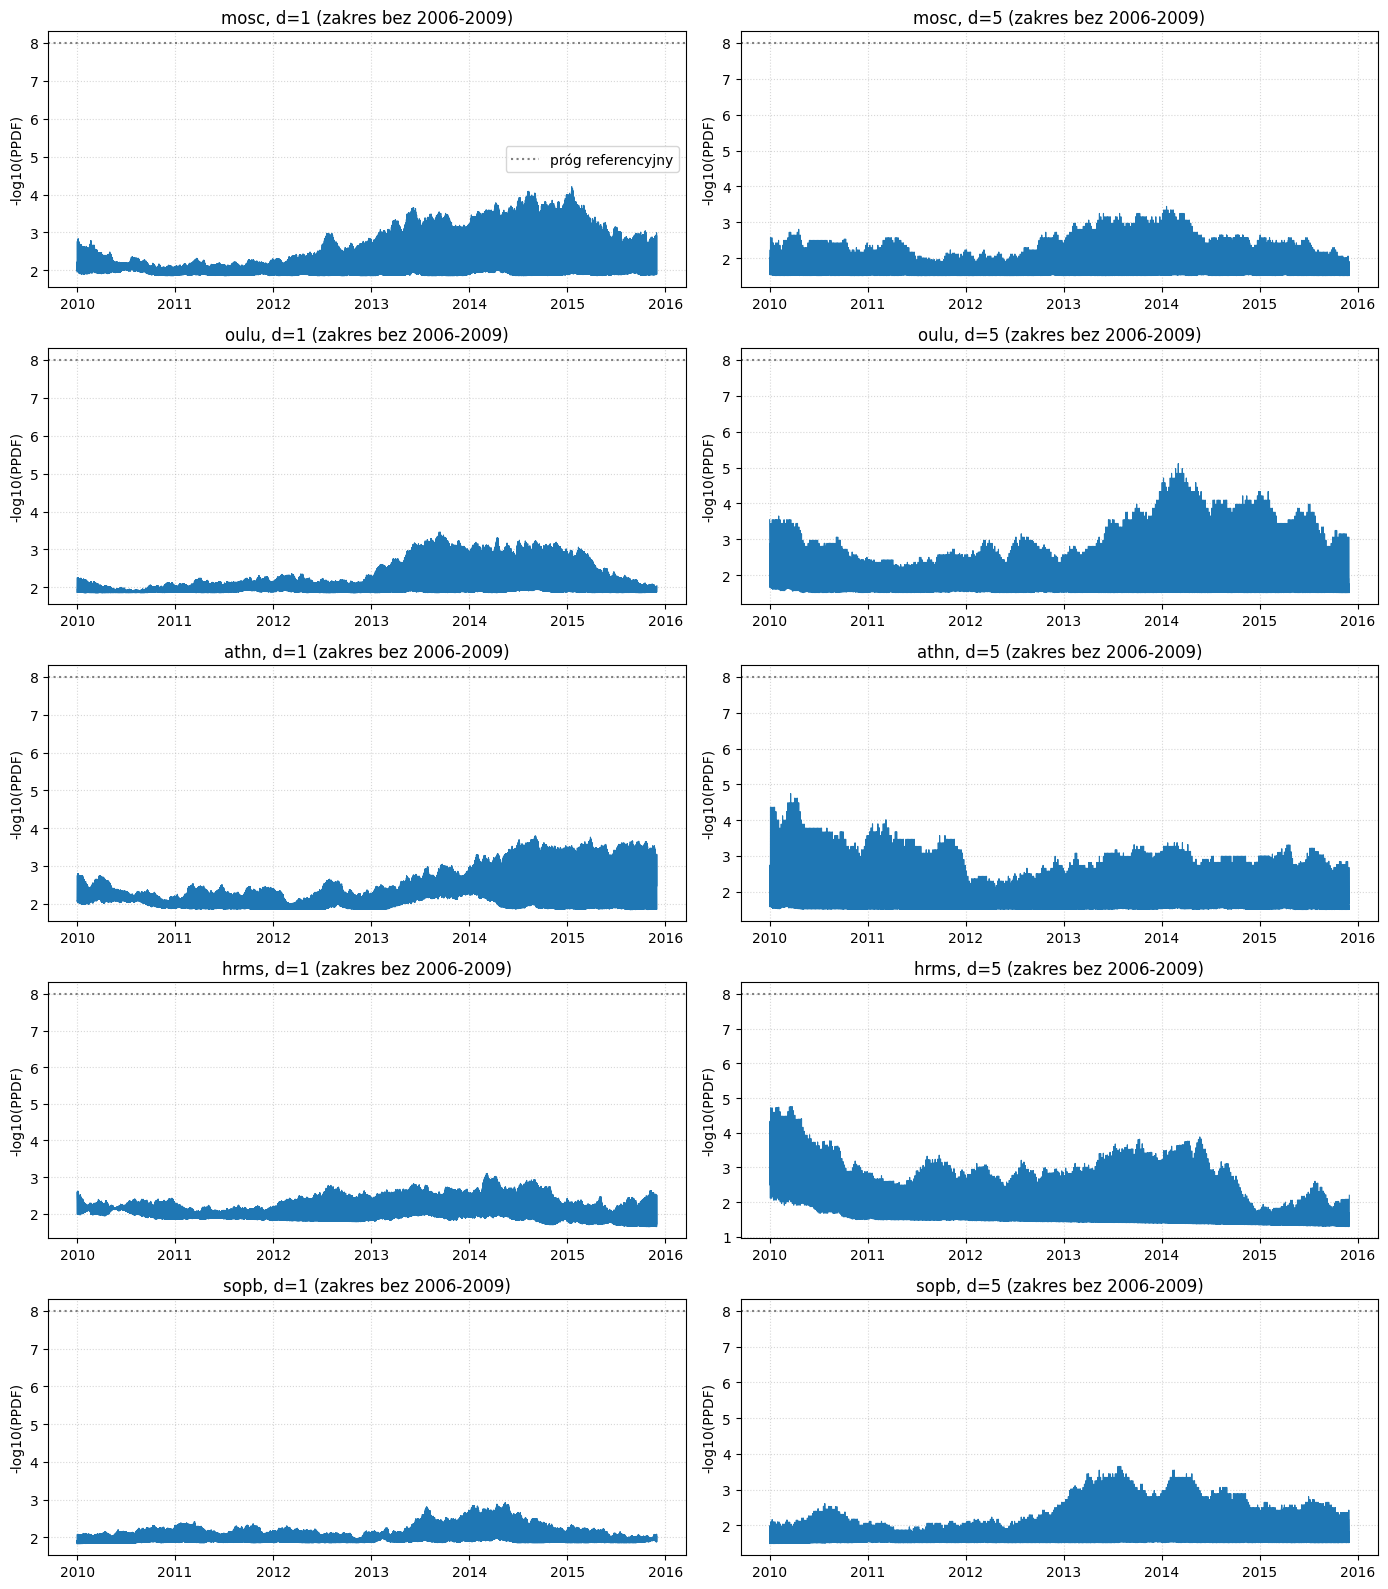

In [7]:
# Wykresy PPDF vs t0 (zakres 2010-2015, bez 2006-2009) per stacja, d=1 i d=5
# obok siebie - zeby zobaczyc wprost, czy w NOWYM zakresie jest jakis
# wyrazny lokalny ekstremum, czy krzywa jest plaska/szumowa. Linia progu
# referencyjnego naniesiona dla porownania.
fig, axes = plt.subplots(len(scan_results), 2, figsize=(14, 3.2 * len(scan_results)), squeeze=False)
for row_i, name in enumerate(scan_results):
    for col_i, d in enumerate(D_VALUES):
        ax = axes[row_i][col_i]
        df_scan = scan_results[name][d].dropna(subset=["PPDF"])
        log10_ppdf = np.where(df_scan["PPDF"] > 0, np.log10(df_scan["PPDF"]), -np.inf)
        ax.plot(df_scan["t0"], -log10_ppdf, lw=0.8)
        ax.axhline(-HOMOLA_LOG10_PPDF_BENCHMARK, color="gray", ls=":", label="próg referencyjny")
        ax.set_title(f"{name}, d={d} (zakres bez 2006-2009)")
        ax.set_ylabel("-log10(PPDF)")
        ax.grid(ls=":", alpha=0.5)
        if row_i == 0 and col_i == 0:
            ax.legend()
fig.tight_layout()
fig.savefig("../results/t0_scan_excl2009_plot.png", dpi=120)
plt.show()
